# CIRRUS Evaluation Notebook

Dieses Notebook ist als **praktischer Startpunkt für die Evaluation von CIRRUS** gedacht.

Es prüft drei Dinge:

1. **Feature Profiling / Recommendation Plausibility**  
   Für jede CSV und jedes relevante Eye-Tracking-Feature werden Missing Rate, IQR-Outlier-Rate, Skewness und Kurtosis berechnet. Daraus wird dieselbe Art von CIRRUS-Empfehlung abgeleitet wie in der Streamlit-App.

2. **Controlled Degradation Test**  
   Saubere Signale werden künstlich verschlechtert: zusätzliche Missing Values, Outliers und Skewness. Danach wird geprüft, ob CIRRUS seine Empfehlung plausibel verändert.

3. **Downstream Evaluation für den Cheating-Datensatz**  
   Wenn Dateien in den Ordnern `Schummeln` und `Nicht_Schummeln` liegen, wird pro Datei ein Feature-Vektor gebildet. Dann werden mehrere Preprocessing-Pipelines mit Random Forest verglichen.

Wichtig: Das ist noch keine perfekte finale Evaluation. Aber es ist ein sauberer Anfang, mit dem du Tabellen für ADBIS erzeugen kannst.

In [1]:
# Falls nötig:
# !pip install pandas numpy scipy scikit-learn matplotlib

from pathlib import Path
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy.stats import skew
from scipy.stats import median_abs_deviation

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

import matplotlib.pyplot as plt

## 1. Pfade einstellen

Die Pfade sind auf deine lokalen Ordner vorbereitet.

Für den Cheating-Datensatz gilt: Das Label kommt **aus dem Ordnernamen**:
- `Schummeln` → `label = 1`
- `Nicht_Schummeln` → `label = 0`

In [2]:
# Lokale Pfade bei dir auf Windows
AUTISM_DIR = Path(r"C:\Users\oxije\Dropbox\Dissertation\Konferenzen\adbis\aut\Eye-tracking Output")

CHEATING_DIRS = {
    "cheating": Path(r"C:\Users\oxije\Dropbox\Dissertation\Konferenzen\adbis\cht\Schummeln"),
    "non_cheating": Path(r"C:\Users\oxije\Dropbox\Dissertation\Konferenzen\adbis\cht\Nicht_Schummeln"),
}

# Ausgabeordner
RESULT_DIR = Path("cirrus_eval_results")
RESULT_DIR.mkdir(exist_ok=True)

# Fallback für diesen Chat-Sandbox-Test:
# Diese Dateien existieren nur hier im Chat-Container, nicht automatisch bei dir lokal.
SAMPLE_AUTISM_FILE = Path("/mnt/data/4.csv")
SAMPLE_CHEATING_FILE = Path("/mnt/data/Frage_1_005_TN1_edit.csv")

print("Autism dir exists:", AUTISM_DIR.exists())
print("Cheating dir exists:", CHEATING_DIRS["cheating"].exists())
print("Non-cheating dir exists:", CHEATING_DIRS["non_cheating"].exists())
print("Result dir:", RESULT_DIR.resolve())

Autism dir exists: True
Cheating dir exists: True
Non-cheating dir exists: True
Result dir: C:\Users\oxije\Dropbox\Dissertation\Konferenzen\adbis\cirrus_eval_results


## 2. Hilfsfunktionen: robustes Einlesen und numerische Spalten

Die Autism-Dateien enthalten teilweise `-` als Platzhalter für fehlende Werte.  
Die Cheating-Dateien enthalten viele NaNs und manchmal geräte-/exportbedingte Sonderwerte.  
Deshalb liest das Notebook CSVs defensiv ein und wandelt geeignete Spalten in numerische Werte um.

In [3]:
def read_csv_robust(path: Path) -> pd.DataFrame:
    """
    Robust CSV reader for exported eye-tracking files.
    Tries common encodings and separators.
    """
    path = Path(path)
    attempts = [
        {"encoding": "utf-8", "sep": ","},
        {"encoding": "utf-8", "sep": ";"},
        {"encoding": "latin1", "sep": ","},
        {"encoding": "latin1", "sep": ";"},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            df = pd.read_csv(path, **kwargs, low_memory=False)
            if df.shape[1] > 1:
                return df
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not read {path}: {last_error}")


def to_numeric_series(s: pd.Series) -> pd.Series:
    """
    Converts strings with commas, '-' placeholders and blanks to numeric.
    """
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    s2 = s.astype(str).str.strip().str.replace(",", ".", regex=False)
    s2 = s2.replace({"-": np.nan, "": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(s2, errors="coerce")


def numeric_eye_tracking_frame(df: pd.DataFrame, min_numeric_ratio: float = 0.15) -> pd.DataFrame:
    """
    Converts all columns that contain at least min_numeric_ratio numeric values.
    Keeps only numeric columns.
    Handles duplicate column names by iterating over column positions.
    """
    converted = {}
    seen = {}
    for i, col in enumerate(df.columns):
        raw_col = df.iloc[:, i]
        ser = to_numeric_series(raw_col)
        ratio = ser.notna().mean()
        if ratio >= min_numeric_ratio:
            col_name = str(col)
            if col_name in seen:
                seen[col_name] += 1
                col_name = f"{col_name}__dup{seen[str(col)]}"
            else:
                seen[col_name] = 0
            converted[col_name] = ser
    return pd.DataFrame(converted)


def list_csv_files_for_dataset():
    """
    Returns a table of available CSV files.
    Uses local folders if they exist, otherwise the two uploaded sample files in this environment.
    """
    records = []

    if AUTISM_DIR.exists():
        for p in sorted(AUTISM_DIR.glob("*.csv")):
            records.append({"dataset": "autism", "path": p, "label": np.nan})
    elif SAMPLE_AUTISM_FILE.exists():
        records.append({"dataset": "autism_sample", "path": SAMPLE_AUTISM_FILE, "label": np.nan})

    if CHEATING_DIRS["cheating"].exists():
        for p in sorted(CHEATING_DIRS["cheating"].glob("*.csv")):
            records.append({"dataset": "cheating", "path": p, "label": 1})
    if CHEATING_DIRS["non_cheating"].exists():
        for p in sorted(CHEATING_DIRS["non_cheating"].glob("*.csv")):
            records.append({"dataset": "cheating", "path": p, "label": 0})

    if not any(r["dataset"] == "cheating" for r in records) and SAMPLE_CHEATING_FILE.exists():
        records.append({"dataset": "cheating_sample", "path": SAMPLE_CHEATING_FILE, "label": 1})

    return pd.DataFrame(records)


files_df = list_csv_files_for_dataset()
files_df

,dataset,path,label
0,autism,C:\Users\oxije\Dropbox\Dissertation\Konferenze...,NaN
1,autism,C:\Users\oxije\Dropbox\Dissertation\Konferenze...,NaN
2,autism,C:\Users\oxije\Dropbox\Dissertation\Konferenze...,NaN
3,autism,C:\Users\oxije\Dropbox\Dissertation\Konferenze...,NaN
4,autism,C:\Users\oxije\Dropbox\Dissertation\Konferenze...,NaN
...,...,...,...
170,cheating,C:\Users\oxije\Dropbox\Dissertation\Konferenze...,0.0
171,cheating,C:\Users\oxije\Dropbox\Dissertation\Konferenze...,0.0
172,cheating,C:\Users\oxije\Dropbox\Dissertation\Konferenze...,0.0
173,cheating,C:\Users\oxije\Dropbox\Dissertation\Konferenze...,0.0


## 3. CIRRUS-Metriken und Empfehlungen

Hier werden die Regeln aus deiner App in Notebook-Form nachgebaut.

Die Regeln sind bewusst transparent. Genau das ist später auch die Verteidigung gegen die Reviewer-Kritik: nicht behaupten, dass es perfekte objektive Metriken sind, sondern zeigen, dass sie explizit, reproduzierbar und empirisch testbar sind.

In [4]:
def iqr_outlier_rate(x: pd.Series) -> float:
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 3:
        return 0.0
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    if iqr <= 0 or np.isnan(iqr):
        return 0.0
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((x < lower) | (x > upper)).mean() * 100)


def feature_profile(x: pd.Series) -> dict:
    x = pd.Series(x).astype(float)
    non_na = x.dropna()
    if len(non_na) < 3:
        return {
            "missing_rate": float(x.isna().mean() * 100),
            "outlier_rate_iqr": 0.0,
            "skewness": 0.0,
            "kurtosis_excess": 0.0,
            "n_nonmissing": int(len(non_na)),
        }
    return {
        "missing_rate": float(x.isna().mean() * 100),
        "outlier_rate_iqr": iqr_outlier_rate(x),
        "skewness": float(skew(non_na, nan_policy="omit")),
        "kurtosis_excess": float(non_na.kurt()),
        "n_nonmissing": int(len(non_na)),
    }


def recommend_missing_method(missing_rate: float) -> str:
    if missing_rate < 5:
        return "LOCF_or_Mean"
    elif missing_rate <= 10:
        return "KNN"
    elif missing_rate <= 20:
        return "KNN_or_MICE"
    else:
        return "KNN_or_MICE_critical"


def recommend_outlier_method(outlier_rate: float, skewness: float) -> str:
    gaussian = abs(skewness) < 0.5
    highly_skewed = abs(skewness) > 1.0
    if outlier_rate < 5 and gaussian:
        return "ZScore"
    elif outlier_rate <= 15:
        if highly_skewed:
            return "MAD_or_IsolationForest"
        else:
            return "IQR_or_IsolationForest"
    else:
        return "IsolationForest"


def recommend_norm_method(skewness: float, outlier_rate: float) -> str:
    if abs(skewness) < 0.5 and outlier_rate < 10:
        return "StandardScaler"
    elif outlier_rate > 15 or abs(skewness) > 1.0:
        return "RobustScaler"
    else:
        return "MinMaxScaler"


def recommend_pipeline(profile: dict) -> dict:
    mv = recommend_missing_method(profile["missing_rate"])
    out = recommend_outlier_method(profile["outlier_rate_iqr"], profile["skewness"])
    norm = recommend_norm_method(profile["skewness"], profile["outlier_rate_iqr"])
    return {
        "recommended_missing": mv,
        "recommended_outlier": out,
        "recommended_normalization": norm,
        "recommended_pipeline": f"{mv} + {out} + {norm}"
    }


def is_relevant_eye_feature(col: str) -> bool:
    """
    Keeps typical eye-tracking signal columns and removes obvious IDs / categorical encodings.
    """
    c = col.lower()
    exclude = [
        "unnamed", "row", "index", "participant", "trial",
        "recordingtime", "export start", "export end",
        "timestamp", "duration"
    ]
    if any(e in c for e in exclude):
        return False

    include = [
        "gaze", "pupil", "fixation", "saccade", "distance",
        "point of regard", "eye position", "pupil position", "vector"
    ]
    return any(i in c for i in include)

## 4. Evaluation 1: Profiling und Empfehlungen für alle verfügbaren Dateien

Das erzeugt deine erste wichtige Tabelle:

`cirrus_feature_profile_recommendations.csv`

Diese Tabelle kannst du später im Paper verdichten: z. B. nur die wichtigsten 8–12 Features zeigen und den Rest als Repository/Appendix.

In [5]:
def profile_one_file(path: Path, dataset: str, label=np.nan, max_features: int = 40) -> pd.DataFrame:
    raw = read_csv_robust(path)
    num = numeric_eye_tracking_frame(raw)

    relevant_cols = [c for c in num.columns if is_relevant_eye_feature(c)]
    if not relevant_cols:
        relevant_cols = list(num.columns)

    relevant_cols = [c for c in relevant_cols if num[c].notna().mean() >= 0.02]
    relevant_cols = relevant_cols[:max_features]

    rows = []
    for col in relevant_cols:
        prof = feature_profile(num[col])
        rec = recommend_pipeline(prof)
        rows.append({
            "dataset": dataset,
            "file": Path(path).name,
            "label": label,
            "feature": col,
            **prof,
            **rec
        })
    return pd.DataFrame(rows)


all_profiles = []
for _, row in files_df.iterrows():
    try:
        prof_df = profile_one_file(row["path"], row["dataset"], row["label"])
        all_profiles.append(prof_df)
    except Exception as e:
        print("Could not profile", row["path"], "->", e)

profile_results = pd.concat(all_profiles, ignore_index=True) if all_profiles else pd.DataFrame()
profile_results.to_csv(RESULT_DIR / "cirrus_feature_profile_recommendations.csv", index=False)

print("Rows:", len(profile_results))
display(profile_results.head(20))
print("Saved:", RESULT_DIR / "cirrus_feature_profile_recommendations.csv")

Rows: 3793


,dataset,file,label,feature,missing_rate,outlier_rate_iqr,skewness,kurtosis_excess,n_nonmissing,recommended_missing,recommended_outlier,recommended_normalization,recommended_pipeline
0,autism,1.csv,NaN,Pupil Diameter Right [mm],0.060641,0.026005,0.260148,-0.430032,34609,LOCF_or_Mean,ZScore,StandardScaler,LOCF_or_Mean + ZScore + StandardScaler
1,autism,1.csv,NaN,Pupil Diameter Left [mm],0.060641,0.043341,0.101638,-0.459205,34609,LOCF_or_Mean,ZScore,StandardScaler,LOCF_or_Mean + ZScore + StandardScaler
2,autism,1.csv,NaN,Point of Regard Right X [px],0.060641,0.000000,0.209774,-0.868428,34609,LOCF_or_Mean,ZScore,StandardScaler,LOCF_or_Mean + ZScore + StandardScaler
3,autism,1.csv,NaN,Point of Regard Right Y [px],0.060641,0.531654,0.488898,0.442338,34609,LOCF_or_Mean,ZScore,StandardScaler,LOCF_or_Mean + ZScore + StandardScaler
4,autism,1.csv,NaN,Point of Regard Left X [px],0.060641,0.000000,0.209774,-0.868428,34609,LOCF_or_Mean,ZScore,StandardScaler,LOCF_or_Mean + ZScore + StandardScaler
5,autism,1.csv,NaN,Point of Regard Left Y [px],0.060641,0.531654,0.488898,0.442338,34609,LOCF_or_Mean,ZScore,StandardScaler,LOCF_or_Mean + ZScore + StandardScaler
6,autism,1.csv,NaN,Gaze Vector Right X,0.060641,0.000000,NaN,0.000000,34609,LOCF_or_Mean,IQR_or_IsolationForest,MinMaxScaler,LOCF_or_Mean + IQR_or_IsolationForest + MinMax...
7,autism,1.csv,NaN,Gaze Vector Right Y,0.060641,0.000000,NaN,0.000000,34609,LOCF_or_Mean,IQR_or_IsolationForest,MinMaxScaler,LOCF_or_Mean + IQR_or_IsolationForest + MinMax...
8,autism,1.csv,NaN,Gaze Vector Right Z,0.060641,0.000000,NaN,0.000000,34609,LOCF_or_Mean,IQR_or_IsolationForest,MinMaxScaler,LOCF_or_Mean + IQR_or_IsolationForest + MinMax...
9,autism,1.csv,NaN,Gaze Vector Left X,0.060641,0.000000,NaN,0.000000,34609,LOCF_or_Mean,IQR_or_IsolationForest,MinMaxScaler,LOCF_or_Mean + IQR_or_IsolationForest + MinMax...


Saved: cirrus_eval_results\cirrus_feature_profile_recommendations.csv


In [6]:
if not profile_results.empty:
    summary_recs = (
        profile_results
        .groupby(["dataset", "recommended_missing", "recommended_outlier", "recommended_normalization"])
        .size()
        .reset_index(name="n_features")
        .sort_values(["dataset", "n_features"], ascending=[True, False])
    )
    display(summary_recs)
    summary_recs.to_csv(RESULT_DIR / "cirrus_recommendation_summary.csv", index=False)

,dataset,recommended_missing,recommended_outlier,recommended_normalization,n_features
3,autism,LOCF_or_Mean,IQR_or_IsolationForest,MinMaxScaler,191
7,autism,LOCF_or_Mean,ZScore,StandardScaler,160
5,autism,LOCF_or_Mean,IsolationForest,RobustScaler,103
6,autism,LOCF_or_Mean,MAD_or_IsolationForest,RobustScaler,56
4,autism,LOCF_or_Mean,IQR_or_IsolationForest,StandardScaler,12
1,autism,KNN,ZScore,StandardScaler,4
2,autism,KNN_or_MICE,ZScore,StandardScaler,4
0,autism,KNN,IQR_or_IsolationForest,MinMaxScaler,2
21,cheating,KNN_or_MICE_critical,MAD_or_IsolationForest,RobustScaler,723
22,cheating,KNN_or_MICE_critical,ZScore,StandardScaler,708


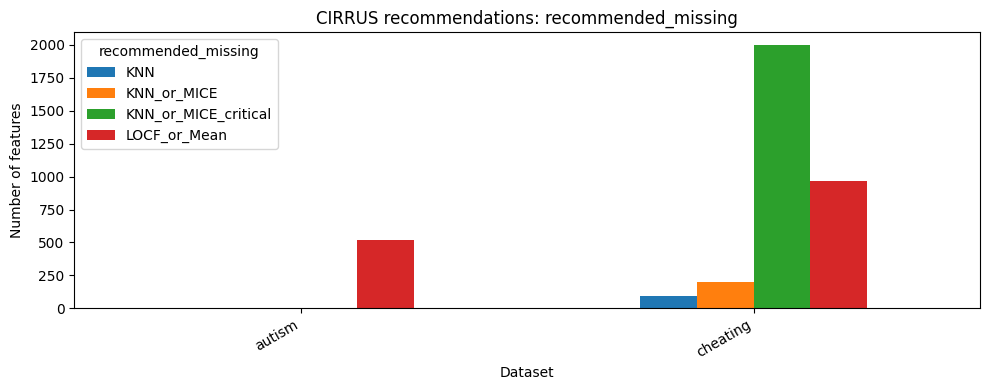

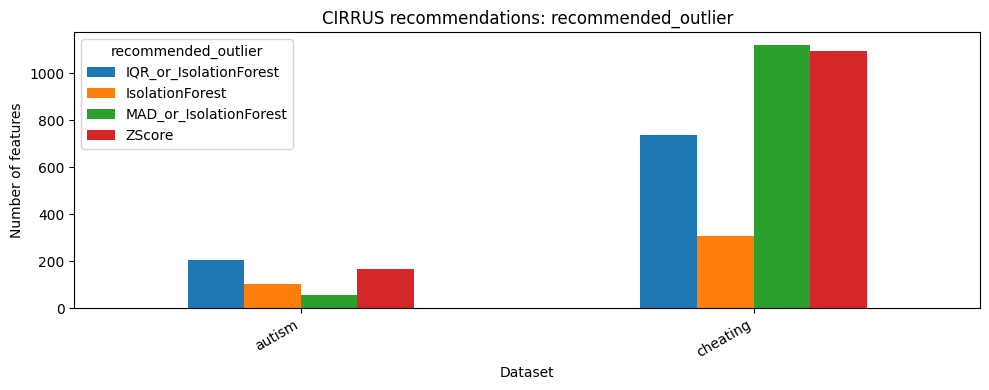

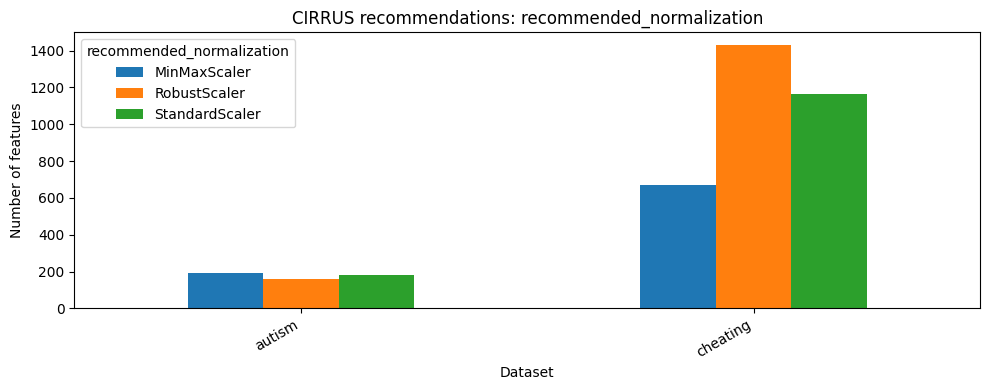

In [7]:
if not profile_results.empty:
    for col in ["recommended_missing", "recommended_outlier", "recommended_normalization"]:
        tab = profile_results.groupby(["dataset", col]).size().unstack(fill_value=0)
        ax = tab.plot(kind="bar", figsize=(10, 4))
        ax.set_title(f"CIRRUS recommendations: {col}")
        ax.set_ylabel("Number of features")
        ax.set_xlabel("Dataset")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

## 5. Evaluation 2: Controlled Degradation Test

Hier kommt der wichtige methodische Punkt gegen die Kritik „nur heuristisch“:

Wir nehmen ein halbwegs vollständiges Signal und verschlechtern es kontrolliert:

- künstliche Missing Values,
- künstliche Outliers,
- künstliche Skewness.

Dann prüfen wir, ob CIRRUS systematisch andere Empfehlungen ausgibt.

In [8]:
def choose_degradation_signal(files_df: pd.DataFrame):
    """
    Pick a suitable numeric feature from the available files.
    Prefer autism pupil diameter if available; otherwise use the first good signal.
    """
    for _, row in files_df.iterrows():
        raw = read_csv_robust(row["path"])
        num = numeric_eye_tracking_frame(raw)
        candidates = [c for c in num.columns if "pupil diameter right" in c.lower()]
        candidates += [c for c in num.columns if is_relevant_eye_feature(c)]
        candidates += list(num.columns)

        for c in candidates:
            x = num[c].dropna()
            if len(x) >= 100 and x.nunique() > 20:
                return row["dataset"], row["path"], c, num[c].astype(float)
    return None, None, None, None


def add_missing(x: pd.Series, rate: float, seed: int = 42) -> pd.Series:
    rng = np.random.default_rng(seed)
    y = x.copy().astype(float)
    valid_idx = np.where(y.notna())[0]
    n = int(len(valid_idx) * rate)
    if n > 0:
        miss_idx = rng.choice(valid_idx, size=n, replace=False)
        y.iloc[miss_idx] = np.nan
    return y


def add_outliers(x: pd.Series, rate: float, magnitude: float = 8.0, seed: int = 42) -> pd.Series:
    rng = np.random.default_rng(seed)
    y = x.copy().astype(float)
    non_na = y.dropna()
    if len(non_na) < 5:
        return y
    idx = non_na.index.to_numpy()
    n = int(len(idx) * rate)
    if n > 0:
        chosen = rng.choice(idx, size=n, replace=False)
        sd = non_na.std()
        if sd == 0 or np.isnan(sd):
            sd = 1.0
        signs = rng.choice([-1, 1], size=n)
        y.loc[chosen] = y.loc[chosen] + signs * magnitude * sd
    return y


def add_skewness(x: pd.Series, strength: float = 1.0) -> pd.Series:
    y = x.copy().astype(float)
    non_na = y.dropna()
    if len(non_na) < 5:
        return y
    mn = non_na.min()
    shifted = y - mn + 1e-6
    return np.power(shifted, 1 + strength)


deg_dataset, deg_path, deg_feature, base_signal = choose_degradation_signal(files_df)
print("Chosen signal:", deg_dataset, Path(deg_path).name if deg_path else None, deg_feature)

degradation_rows = []
if base_signal is not None:
    scenarios = []
    scenarios.append(("original", base_signal))

    for r in [0.05, 0.10, 0.20, 0.40]:
        scenarios.append((f"missing_{int(r*100)}", add_missing(base_signal, r)))

    for r in [0.05, 0.10, 0.20]:
        scenarios.append((f"outliers_{int(r*100)}", add_outliers(base_signal, r)))

    for s in [0.5, 1.0, 2.0]:
        scenarios.append((f"skew_strength_{s}", add_skewness(base_signal, s)))

    mixed = add_missing(base_signal, 0.20)
    mixed = add_outliers(mixed, 0.10)
    mixed = add_skewness(mixed, 1.0)
    scenarios.append(("mixed_missing20_outlier10_skew", mixed))

    for scenario, x in scenarios:
        prof = feature_profile(pd.Series(x))
        rec = recommend_pipeline(prof)
        degradation_rows.append({
            "source_dataset": deg_dataset,
            "source_file": Path(deg_path).name,
            "source_feature": deg_feature,
            "scenario": scenario,
            **prof,
            **rec
        })

degradation_results = pd.DataFrame(degradation_rows)
degradation_results.to_csv(RESULT_DIR / "cirrus_controlled_degradation_test.csv", index=False)

display(degradation_results)
print("Saved:", RESULT_DIR / "cirrus_controlled_degradation_test.csv")

Chosen signal: autism 1.csv Pupil Diameter Right [mm]


,source_dataset,source_file,source_feature,scenario,missing_rate,outlier_rate_iqr,skewness,kurtosis_excess,n_nonmissing,recommended_missing,recommended_outlier,recommended_normalization,recommended_pipeline
0,autism,1.csv,Pupil Diameter Right [mm],original,0.060641,0.026005,0.260148,-0.430032,34609,LOCF_or_Mean,ZScore,StandardScaler,LOCF_or_Mean + ZScore + StandardScaler
1,autism,1.csv,Pupil Diameter Right [mm],missing_5,5.056310,0.030415,0.257998,-0.427113,32879,KNN,ZScore,StandardScaler,KNN + ZScore + StandardScaler
2,autism,1.csv,Pupil Diameter Right [mm],missing_10,10.051978,0.022473,0.262000,-0.432965,31149,KNN_or_MICE,ZScore,StandardScaler,KNN_or_MICE + ZScore + StandardScaler
3,autism,1.csv,Pupil Diameter Right [mm],missing_20,20.046203,0.025282,0.259025,-0.427468,27688,KNN_or_MICE_critical,ZScore,StandardScaler,KNN_or_MICE_critical + ZScore + StandardScaler
4,autism,1.csv,Pupil Diameter Right [mm],missing_40,40.034652,0.024078,0.247121,-0.435803,20766,KNN_or_MICE_critical,ZScore,StandardScaler,KNN_or_MICE_critical + ZScore + StandardScaler
5,autism,1.csv,Pupil Diameter Right [mm],outliers_5,0.060641,5.024705,-0.041815,9.895870,34609,LOCF_or_Mean,IQR_or_IsolationForest,StandardScaler,LOCF_or_Mean + IQR_or_IsolationForest + Standa...
6,autism,1.csv,Pupil Diameter Right [mm],outliers_10,0.060641,10.017625,-0.050594,5.245300,34609,LOCF_or_Mean,IQR_or_IsolationForest,MinMaxScaler,LOCF_or_Mean + IQR_or_IsolationForest + MinMax...
7,autism,1.csv,Pupil Diameter Right [mm],outliers_20,0.060641,20.012136,-0.013593,1.714214,34609,LOCF_or_Mean,IsolationForest,RobustScaler,LOCF_or_Mean + IsolationForest + RobustScaler
8,autism,1.csv,Pupil Diameter Right [mm],skew_strength_0.5,0.060641,1.109538,0.534254,-0.078509,34609,LOCF_or_Mean,IQR_or_IsolationForest,MinMaxScaler,LOCF_or_Mean + IQR_or_IsolationForest + MinMax...
9,autism,1.csv,Pupil Diameter Right [mm],skew_strength_1.0,0.060641,1.225115,0.814417,0.583794,34609,LOCF_or_Mean,IQR_or_IsolationForest,MinMaxScaler,LOCF_or_Mean + IQR_or_IsolationForest + MinMax...


Saved: cirrus_eval_results\cirrus_controlled_degradation_test.csv


## 6. Evaluation 3: Imputation Benchmark auf künstlich maskierten Werten

Das ist stärker als nur „Empfehlung ansehen“:

Wir nehmen beobachtete Werte, maskieren sie künstlich und wissen deshalb die Wahrheit.  
Dann vergleichen wir, wie gut verschiedene Imputationsmethoden die entfernten Werte rekonstruieren.

Metrik: **RMSE auf künstlich entfernten Werten**.  
Niedriger ist besser.

In [9]:
def impute_dataframe(df_num: pd.DataFrame, method: str) -> pd.DataFrame:
    X = df_num.copy().astype(float)
    X = X.dropna(axis=1, how="all")
    if X.empty:
        return X

    if method == "mean":
        return X.fillna(X.mean(numeric_only=True))
    if method == "locf":
        return X.ffill().bfill().fillna(X.mean(numeric_only=True))
    if method == "linear":
        return X.interpolate(limit_direction="both").fillna(X.mean(numeric_only=True))
    if method == "knn":
        try:
            arr = KNNImputer(n_neighbors=min(5, max(1, len(X)-1))).fit_transform(X)
            return pd.DataFrame(arr, columns=X.columns, index=X.index)
        except Exception:
            return X.fillna(X.mean(numeric_only=True))
    if method == "mice":
        try:
            arr = IterativeImputer(max_iter=10, random_state=42, sample_posterior=False).fit_transform(X)
            return pd.DataFrame(arr, columns=X.columns, index=X.index)
        except Exception:
            return X.fillna(X.mean(numeric_only=True))
    raise ValueError(method)


def imputation_benchmark_one_file(path: Path, dataset: str, missing_rates=(0.05, 0.10, 0.20), seed=42):
    raw = read_csv_robust(path)
    num = numeric_eye_tracking_frame(raw)
    cols = [c for c in num.columns if is_relevant_eye_feature(c) and num[c].notna().mean() > 0.7]
    cols = cols[:12]
    if len(cols) < 2:
        return pd.DataFrame()

    X_full = num[cols].copy().astype(float)
    X_ref = X_full.dropna()
    if len(X_ref) < 100:
        X_ref = X_full.fillna(X_full.mean()).dropna()
    if len(X_ref) < 50:
        return pd.DataFrame()

    X_ref = X_ref.iloc[:5000].copy()

    rng = np.random.default_rng(seed)
    rows = []
    for rate in missing_rates:
        mask = pd.DataFrame(False, index=X_ref.index, columns=X_ref.columns)
        for col in X_ref.columns:
            idx = X_ref.index.to_numpy()
            n = int(len(idx) * rate)
            chosen = rng.choice(idx, size=n, replace=False)
            mask.loc[chosen, col] = True

        X_masked = X_ref.mask(mask)

        for method in ["mean", "locf", "linear", "knn", "mice"]:
            X_imp = impute_dataframe(X_masked, method)
            common_cols = [c for c in X_ref.columns if c in X_imp.columns]
            diffs = []
            for col in common_cols:
                m = mask[col]
                if m.sum() > 0:
                    diff = X_imp.loc[m, col] - X_ref.loc[m, col]
                    diffs.extend(diff.dropna().to_numpy())
            rmse = float(np.sqrt(np.mean(np.square(diffs)))) if len(diffs) else np.nan
            rows.append({
                "dataset": dataset,
                "file": Path(path).name,
                "missing_rate_inserted": rate,
                "method": method,
                "rmse_masked_values": rmse,
                "n_features": len(common_cols),
                "n_rows": len(X_ref)
            })
    return pd.DataFrame(rows)


bench_rows = []
for _, row in files_df.iterrows():
    try:
        b = imputation_benchmark_one_file(row["path"], row["dataset"])
        if not b.empty:
            bench_rows.append(b)
    except Exception as e:
        print("Benchmark failed:", row["path"], e)

imputation_benchmark = pd.concat(bench_rows, ignore_index=True) if bench_rows else pd.DataFrame()
imputation_benchmark.to_csv(RESULT_DIR / "cirrus_imputation_benchmark.csv", index=False)

display(imputation_benchmark.head(30))
print("Saved:", RESULT_DIR / "cirrus_imputation_benchmark.csv")

,dataset,file,missing_rate_inserted,method,rmse_masked_values,n_features,n_rows
0,autism,1.csv,0.05,mean,149.955400,12,5000
1,autism,1.csv,0.05,locf,131.196296,12,5000
2,autism,1.csv,0.05,linear,111.414491,12,5000
3,autism,1.csv,0.05,knn,95.536867,12,5000
4,autism,1.csv,0.05,mice,24.673343,12,5000
5,autism,1.csv,0.10,mean,145.863130,12,5000
6,autism,1.csv,0.10,locf,133.485310,12,5000
7,autism,1.csv,0.10,linear,116.622595,12,5000
8,autism,1.csv,0.10,knn,129.814782,12,5000
9,autism,1.csv,0.10,mice,46.056273,12,5000


Saved: cirrus_eval_results\cirrus_imputation_benchmark.csv


,dataset,missing_rate_inserted,method,rmse_masked_values
4,autism,0.05,mice,32.274935
1,autism,0.05,linear,55.423891
0,autism,0.05,knn,59.886728
2,autism,0.05,locf,68.242575
3,autism,0.05,mean,149.289389
9,autism,0.10,mice,39.819740
6,autism,0.10,linear,57.127931
7,autism,0.10,locf,68.991539
5,autism,0.10,knn,79.559557
8,autism,0.10,mean,149.735709


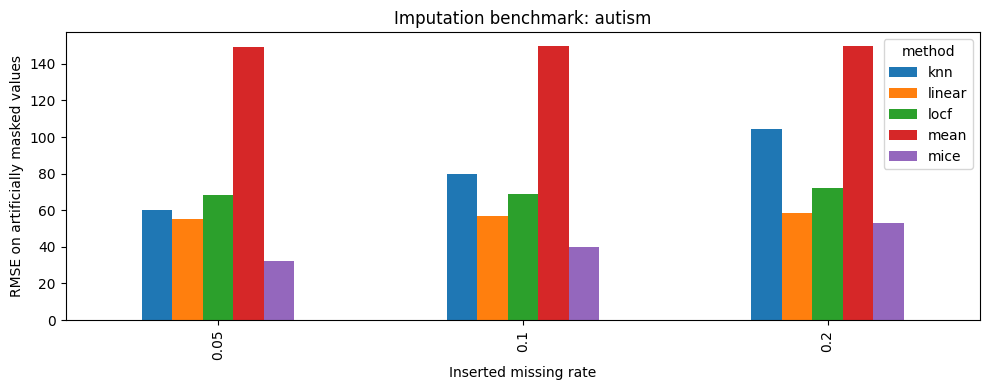

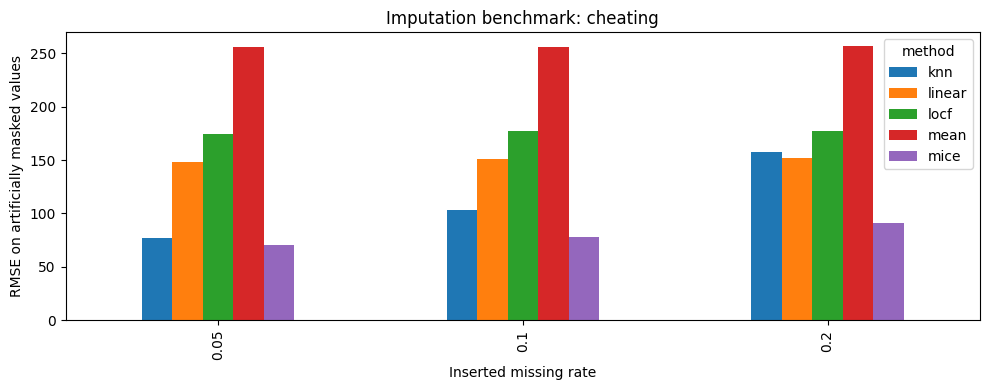

In [10]:
if not imputation_benchmark.empty:
    imp_summary = (
        imputation_benchmark
        .groupby(["dataset", "missing_rate_inserted", "method"])["rmse_masked_values"]
        .mean()
        .reset_index()
        .sort_values(["dataset", "missing_rate_inserted", "rmse_masked_values"])
    )
    display(imp_summary)

    for ds in imp_summary["dataset"].unique():
        sub = imp_summary[imp_summary["dataset"] == ds]
        pivot = sub.pivot(index="missing_rate_inserted", columns="method", values="rmse_masked_values")
        ax = pivot.plot(kind="bar", figsize=(10,4))
        ax.set_title(f"Imputation benchmark: {ds}")
        ax.set_ylabel("RMSE on artificially masked values")
        ax.set_xlabel("Inserted missing rate")
        plt.tight_layout()
        plt.show()

## 7. Evaluation 4: Downstream-Klassifikation für den Cheating-Datensatz

Das läuft nur sinnvoll, wenn du **mehrere Dateien in beiden Ordnern** hast:

- `Schummeln` → Label 1
- `Nicht_Schummeln` → Label 0

Pro CSV wird ein aggregierter Feature-Vektor gebaut: Mittelwert, Standardabweichung, Median, Missing Rate, Outlier Rate und Skewness pro Signal.

Verglichen werden:

- `raw_aggregate`: nur robuste Aggregation ohne vorherige Pipeline
- `simple_default`: Mean + IQR + StandardScaler
- `robust_default`: KNN + MAD + RobustScaler
- `cirrus_recommended`: feature-spezifische CIRRUS-Entscheidung

In [11]:
def handle_outliers_df(X: pd.DataFrame, method: str) -> pd.DataFrame:
    Y = X.copy().astype(float)

    for col in Y.columns:
        x = Y[col]
        non_na = x.dropna()
        if len(non_na) < 5:
            continue

        if method == "none":
            continue

        if method == "iqr":
            q1, q3 = np.percentile(non_na, [25, 75])
            iqr = q3 - q1
            if iqr <= 0 or np.isnan(iqr):
                continue
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            Y.loc[(Y[col] < lower) | (Y[col] > upper), col] = np.nan

        elif method == "mad":
            med = np.median(non_na)
            mad = median_abs_deviation(non_na)
            if mad <= 0 or np.isnan(mad):
                continue
            Y.loc[np.abs(Y[col] - med) > 3 * mad, col] = np.nan

        elif method == "zscore":
            mu, sd = non_na.mean(), non_na.std()
            if sd <= 0 or np.isnan(sd):
                continue
            Y.loc[np.abs((Y[col] - mu) / sd) > 3, col] = np.nan

    return Y


def scale_df(X: pd.DataFrame, method: str) -> pd.DataFrame:
    X = X.copy().astype(float)
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.mean(numeric_only=True)).fillna(0.0)

    if method == "none":
        return X

    if method == "standard":
        scaler = StandardScaler()
    elif method == "robust":
        scaler = RobustScaler()
    elif method == "minmax":
        scaler = MinMaxScaler()
    else:
        raise ValueError(method)

    arr = scaler.fit_transform(X)
    return pd.DataFrame(arr, columns=X.columns, index=X.index)


def apply_pipeline_to_timeseries(num: pd.DataFrame, pipeline: str) -> pd.DataFrame:
    X = num.copy().astype(float)
    cols = [c for c in X.columns if is_relevant_eye_feature(c) and X[c].notna().mean() >= 0.02]
    cols = cols[:30]
    X = X[cols]
    if X.empty:
        return X

    if pipeline == "raw_aggregate":
        return X

    if pipeline == "simple_default":
        X = impute_dataframe(X, "mean")
        X = handle_outliers_df(X, "iqr")
        X = impute_dataframe(X, "mean")
        X = scale_df(X, "standard")
        return X

    if pipeline == "robust_default":
        X = impute_dataframe(X, "knn")
        X = handle_outliers_df(X, "mad")
        X = impute_dataframe(X, "mean")
        X = scale_df(X, "robust")
        return X

    if pipeline == "cirrus_recommended":
        Y = pd.DataFrame(index=X.index)
        for col in X.columns:
            s = X[col].copy()
            prof = feature_profile(s)
            rec = recommend_pipeline(prof)

            mv = rec["recommended_missing"]
            if mv == "LOCF_or_Mean":
                s2 = s.ffill().bfill().fillna(s.mean())
            elif "KNN" in mv:
                s2 = s.copy()
            else:
                s2 = s.fillna(s.mean())

            out = rec["recommended_outlier"]
            tmp = pd.DataFrame({col: s2})
            if out == "ZScore":
                tmp = handle_outliers_df(tmp, "zscore")
            elif "MAD" in out:
                tmp = handle_outliers_df(tmp, "mad")
            elif "IQR" in out:
                tmp = handle_outliers_df(tmp, "iqr")
            elif out == "IsolationForest":
                tmp = handle_outliers_df(tmp, "iqr")
            s2 = tmp[col]

            Y[col] = s2

        if Y.isna().mean().mean() > 0:
            Y = impute_dataframe(Y, "knn")

        Z = pd.DataFrame(index=Y.index)
        for col in Y.columns:
            prof = feature_profile(Y[col])
            norm = recommend_norm_method(prof["skewness"], prof["outlier_rate_iqr"])
            one = Y[[col]].fillna(Y[col].mean()).fillna(0.0)
            if norm == "StandardScaler":
                Z[col] = scale_df(one, "standard")[col]
            elif norm == "RobustScaler":
                Z[col] = scale_df(one, "robust")[col]
            else:
                Z[col] = scale_df(one, "minmax")[col]
        return Z

    raise ValueError(pipeline)


def aggregate_file_features(X: pd.DataFrame, prefix_limit: int = 30) -> dict:
    feats = {}
    if X.empty:
        return feats

    cols = list(X.columns)[:prefix_limit]
    for col in cols:
        s = X[col].astype(float)
        clean_name = re.sub(r"[^A-Za-z0-9]+", "_", col).strip("_")[:60]
        prof = feature_profile(s)
        feats[f"{clean_name}__mean"] = float(s.mean(skipna=True))
        feats[f"{clean_name}__std"] = float(s.std(skipna=True))
        feats[f"{clean_name}__median"] = float(s.median(skipna=True))
        feats[f"{clean_name}__missing"] = prof["missing_rate"]
        feats[f"{clean_name}__outlier_iqr"] = prof["outlier_rate_iqr"]
        feats[f"{clean_name}__skew"] = prof["skewness"]
    return feats


def build_ml_table(files_df: pd.DataFrame, pipeline: str) -> pd.DataFrame:
    rows = []
    cfiles = files_df[files_df["dataset"].eq("cheating")].copy()
    if cfiles.empty:
        return pd.DataFrame()

    for _, row in cfiles.iterrows():
        try:
            raw = read_csv_robust(row["path"])
            num = numeric_eye_tracking_frame(raw)
            prep = apply_pipeline_to_timeseries(num, pipeline)
            feats = aggregate_file_features(prep)
            feats["file"] = Path(row["path"]).name
            feats["label"] = int(row["label"])
            feats["pipeline"] = pipeline
            rows.append(feats)
        except Exception as e:
            print("Failed", pipeline, row["path"], e)
    return pd.DataFrame(rows)


pipelines = ["raw_aggregate", "simple_default", "robust_default", "cirrus_recommended"]

ml_tables = {}
for pipe in pipelines:
    tab = build_ml_table(files_df, pipe)
    ml_tables[pipe] = tab
    print(pipe, tab.shape)

for pipe, tab in ml_tables.items():
    if not tab.empty:
        display(tab.head())
        break

raw_aggregate (150, 171)
simple_default (150, 171)
robust_default (150, 171)
cirrus_recommended (150, 171)


,ET_GazeLeftx__mean,ET_GazeLeftx__std,ET_GazeLeftx__median,ET_GazeLeftx__missing,ET_GazeLeftx__outlier_iqr,ET_GazeLeftx__skew,ET_GazeLefty__mean,ET_GazeLefty__std,ET_GazeLefty__median,ET_GazeLefty__missing,...,Saccade_Peak_Deceleration__median,Saccade_Peak_Deceleration__missing,Saccade_Peak_Deceleration__outlier_iqr,Saccade_Peak_Deceleration__skew,Interocular_Distance__mean,Interocular_Distance__std,Interocular_Distance__median,Interocular_Distance__missing,Interocular_Distance__outlier_iqr,Interocular_Distance__skew
0,469.957754,364.176867,471.0,1.676079,0.000000,0.391777,221.497313,232.703436,188.0,1.676079,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,125.638395,262.986555,-1.0,20.473870,0.000000,2.007685,62.757208,150.102663,-1.0,20.473870,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,346.508169,368.063005,364.0,1.697390,3.843297,1.196148,211.128110,226.423984,-1.0,1.697390,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,372.329069,382.159563,363.0,1.676996,0.037078,0.613841,117.413422,194.799755,-1.0,1.676996,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,35.650187,183.111681,-1.0,20.424107,0.000000,5.063956,17.452899,102.272242,-1.0,20.424107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
def evaluate_ml_table(tab: pd.DataFrame, pipeline_name: str) -> dict:
    if tab.empty:
        return {"pipeline": pipeline_name, "status": "no_data"}

    y = tab["label"].astype(int)
    X = tab.drop(columns=["label", "file", "pipeline"], errors="ignore")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.mean(numeric_only=True)).fillna(0.0)

    n_classes = y.nunique()
    if n_classes < 2:
        return {"pipeline": pipeline_name, "status": "only_one_class", "n_files": len(tab), "n_classes": n_classes}

    min_class = y.value_counts().min()
    if len(tab) < 6 or min_class < 2:
        return {"pipeline": pipeline_name, "status": "too_few_files_for_cv", "n_files": len(tab), "min_class_count": int(min_class)}

    n_splits = min(5, int(min_class))
    clf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        max_features="sqrt",
        min_samples_leaf=1
    )
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    scoring = {
        "accuracy": "accuracy",
        "f1": "f1",
        "roc_auc": "roc_auc",
    }

    try:
        res = cross_validate(clf, X, y, cv=cv, scoring=scoring, error_score=np.nan)
        return {
            "pipeline": pipeline_name,
            "status": "ok",
            "n_files": len(tab),
            "n_features": X.shape[1],
            "n_splits": n_splits,
            "accuracy_mean": float(np.nanmean(res["test_accuracy"])),
            "accuracy_std": float(np.nanstd(res["test_accuracy"])),
            "f1_mean": float(np.nanmean(res["test_f1"])),
            "f1_std": float(np.nanstd(res["test_f1"])),
            "auc_mean": float(np.nanmean(res["test_roc_auc"])),
            "auc_std": float(np.nanstd(res["test_roc_auc"])),
        }
    except Exception as e:
        return {"pipeline": pipeline_name, "status": f"error: {e}", "n_files": len(tab)}


ml_eval_rows = []
for pipe, tab in ml_tables.items():
    ml_eval_rows.append(evaluate_ml_table(tab, pipe))

ml_eval = pd.DataFrame(ml_eval_rows)
ml_eval.to_csv(RESULT_DIR / "cirrus_downstream_ml_comparison.csv", index=False)

display(ml_eval)
print("Saved:", RESULT_DIR / "cirrus_downstream_ml_comparison.csv")

,pipeline,status,n_files,n_features,n_splits,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_mean,auc_std
0,raw_aggregate,ok,150,168,5,0.640000,0.071181,0.717584,0.034939,0.680653,0.136343
1,simple_default,ok,150,168,5,0.620000,0.110755,0.693098,0.107488,0.678062,0.127402
2,robust_default,ok,150,168,5,0.613333,0.140791,0.700199,0.098356,0.697620,0.193281
3,cirrus_recommended,ok,150,168,5,0.686667,0.088443,0.772586,0.054197,0.690502,0.164402


Saved: cirrus_eval_results\cirrus_downstream_ml_comparison.csv


## 8. Ergebnisdateien

Nach dem Durchlauf solltest du im Ordner `cirrus_eval_results` mindestens diese Dateien haben:

- `cirrus_feature_profile_recommendations.csv`  
  Feature-Level-Diagnostik und CIRRUS-Empfehlung.

- `cirrus_recommendation_summary.csv`  
  Kompakte Zusammenfassung der Empfehlungstypen.

- `cirrus_controlled_degradation_test.csv`  
  Kontrollierte Verschlechterung und Reaktion der Heuristik.

- `cirrus_imputation_benchmark.csv`  
  RMSE-Vergleich verschiedener Imputationsmethoden.

- `cirrus_downstream_ml_comparison.csv`  
  Downstream-Klassifikation für Schummeln/Nicht-Schummeln, sofern genug Dateien in beiden Ordnern vorhanden sind.

Für ADBIS ist die stärkste Kombination wahrscheinlich:

1. Feature profiling auf beiden Datensätzen.
2. Controlled degradation als methodische Verteidigung der Heuristiken.
3. Downstream-Klassifikation auf deinem Cheating-Datensatz.

## 9. Vorsichtige Interpretation für später

Du solltest die Ergebnisse nicht überverkaufen. Der saubere Claim ist:

> CIRRUS does not replace statistical validation or domain expertise. Instead, it makes preprocessing decisions explicit, reproducible, and data-dependent. The evaluation shows that its rule-based recommendations react systematically to controlled data quality changes and achieve competitive downstream performance compared to common default preprocessing pipelines.

Das ist deutlich sicherer als zu behaupten, CIRRUS finde immer die optimale Pipeline.